In [1]:

import import_ipynb
import nbimporter
%run ./utils.ipynb  # Esegui il notebook1
from utils import prepareTrainingSet3Sec
from utils import prepareTrainingSet30Sec
from utils import standardization
from utils import evaluate_Model
from utils import Grafico_Before_After

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test= prepareTrainingSet30Sec()


print('FINITO')

FINITO


In [24]:

# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train, X_test= standardization(X_train, X_test)

# Creare il modello SVM
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)

# Calcolo e stampa delle metriche
metrics(y_test, y_pred)
before_30sec=accuracy_score(y_test, y_pred)


Accuratezza: 0.6850
Precision: 0.7116
Recall: 0.7059
F1-score: 0.6999
F2-score: 0.7009


In [5]:
# Permette di testare diverse configurazioni iperparametriche 
param_grid = {
    'C': [1, 10],
    'gamma': ['scale'] + [0.1,1],
    'kernel': ['rbf','poly']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("I Migliori parametri trovati sono:", grid_search.best_params_)
best_model = grid_search.best_estimator_

KeyboardInterrupt: 

In [6]:

# Creare il modello SVM e applico la funzione kernel consiglata dalla Grid
model = SVC(C=10, gamma='scale', kernel='rbf')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)

# Calcolo e stampa delle metriche
metrics(y_test, y_pred)
after_30sec=accuracy_score(y_test, y_pred)
svm30Sec=after_30sec

Accuratezza: 0.7400
Precision: 0.7343
Recall: 0.7464
F1-score: 0.7344
F2-score: 0.7401


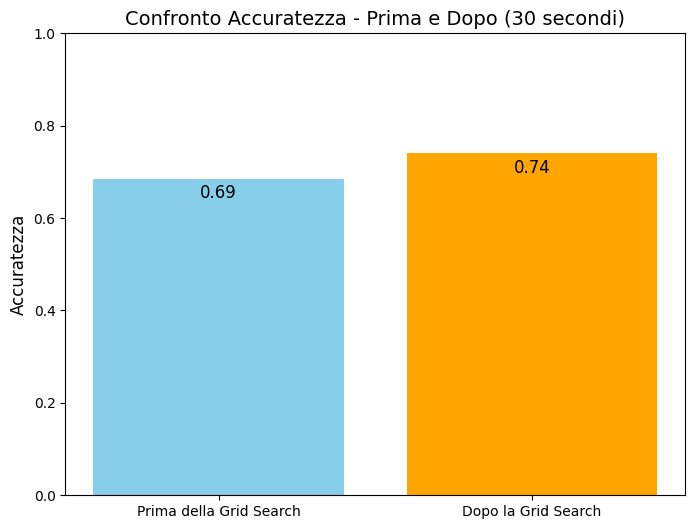

In [7]:
Grafico_Before_After(before_30sec,after_30sec)

In [2]:
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()

In [3]:
X_train, X_test= standardization(X_train, X_test)

# Creare il modello SVM
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)
y_pred_training = model.predict(X_train)

# Calcolo e stampa delle metriche
evaluate_Model(y_test, y_pred, y_train, y_pred_training)
before_3sec=accuracy_score(y_test, y_pred)

Accuratezza: 0.7718
Precision: 0.7706
Recall: 0.7727
F1-score: 0.7701
F2-score: 0.7713
Accuratezza: 0.8059
Precision: 0.8049
Recall: 0.8058
F1-score: 0.8042
F2-score: 0.8049

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


In [ ]:
# Permette di testare diverse configurazioni iperparametriche 
param_grid = {
    'C': [1, 10],
    'gamma': ['scale'] + [0.1,1],
    'kernel': ['rbf','poly']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("I Migliori parametri trovati sono:", grid_search.best_params_)
best_model = grid_search.best_estimator_

KeyboardInterrupt: 

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

# 1. Calcola la cross-validation sul set di training
model = SVC(C=0.3, kernel='rbf')
cross_val_scores = cross_val_score(model, X_train, y_train, cv=10)

# 2. Calcola l'accuratezza sul set di training
model.fit(X_train, y_train)
training_accuracy = model.score(X_train, y_train)

# 3. Calcola la media dei punteggi della cross-validation
cv_accuracy = cross_val_scores.mean()

# 4. Confronta i risultati
print("Accuratezza media della cross-validation:", cv_accuracy)
print("Accuratezza sul training set:", training_accuracy)

# Analisi diagnostica
print("\n=== Analisi ===")
if abs(training_accuracy - cv_accuracy) > 0.05:  # Scarto percentuale del 5%
    print("Il modello potrebbe soffrire di OVERFITTING (performance molto migliore sul training set).")
else:
    print("Il modello sembra bilanciato e generalizza bene.")

Accuratezza media della cross-validation: 0.7760242490613266
Accuratezza sul training set: 0.8243243243243243

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


<h2> Grafico dei 3 secondi

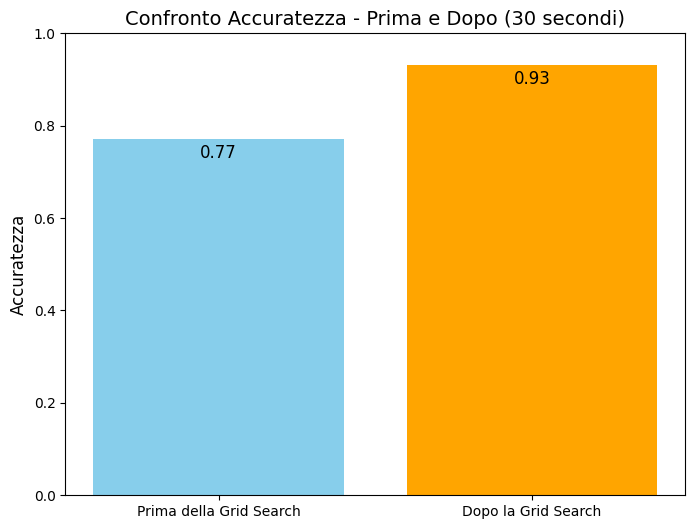

In [11]:
Grafico_Before_After(before_3sec,after_3sec)

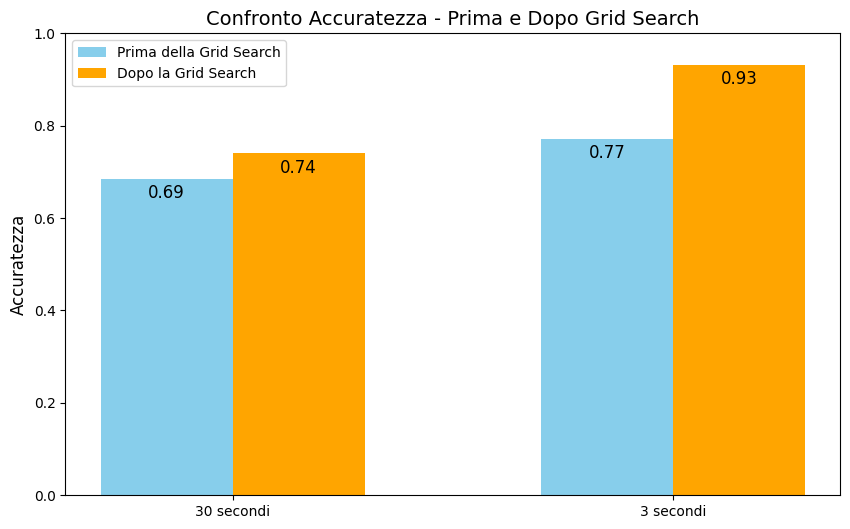

In [13]:
ConfrontoGrafico_30_e_3(before_30sec,before_3sec,after_30sec,after_3sec) 